# 01 — Exploratory Data Analysis
**Movie Recommendation System | Data Mining Midterm**

This notebook explores the ML-32M dataset across four files:
- `ratings.csv` — 32M user-movie ratings
- `movies.csv` — 87K movie titles & genres
- `tags.csv` — 2M user-generated tags
- `links.csv` — external IDs (IMDb, TMDb)


## 0. Imports & Config

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})


In [ ]:
import os

NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))  

DATA_RAW  = os.path.join(PROJECT_ROOT, "data", "raw") + "/"
FIGS_DIR  = os.path.join(PROJECT_ROOT, "results", "figures") + "/"

os.makedirs(FIGS_DIR, exist_ok=True)

RATINGS_PATH = DATA_RAW + "ratings.csv"
MOVIES_PATH  = DATA_RAW + "movies.csv"
TAGS_PATH    = DATA_RAW + "tags.csv"
LINKS_PATH   = DATA_RAW + "links.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RATINGS_PATH:", RATINGS_PATH)

PROJECT_ROOT: d:\DataMining\722I0004_523V0015_523K0078_midterm_DataMining
RATINGS_PATH: d:\DataMining\722I0004_523V0015_523K0078_midterm_DataMining\data\raw/ratings.csv


## 1. Load Data

> `ratings.csv` is ~877 MB. We sample **2M rows** for fast prototyping. Set `SAMPLE = None` to use the full dataset.

In [8]:
SAMPLE = 2_000_000   # Set to None to load all 32M rows

# ratings
if SAMPLE:
    ratings = pd.read_csv(RATINGS_PATH, nrows=SAMPLE)
else:
    ratings = pd.read_csv(RATINGS_PATH)

# other files are small — load fully
movies = pd.read_csv(MOVIES_PATH)
tags   = pd.read_csv(TAGS_PATH)
links  = pd.read_csv(LINKS_PATH)

print(f"ratings : {ratings.shape}")
print(f"movies  : {movies.shape}")
print(f"tags    : {tags.shape}")
print(f"links   : {links.shape}")


ratings : (2000000, 4)
movies  : (87585, 3)
tags    : (2000072, 4)
links   : (87585, 3)


## 2. Basic Info & Missing Values

In [9]:
for name, df in [("ratings", ratings), ("movies", movies), ("tags", tags), ("links", links)]:
    print(f"\n{'='*40}")
    print(f"  {name.upper()}")
    print(f"{'='*40}")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isnull().sum())


  RATINGS
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

Missing values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

  MOVIES
movieId     int64
title      object
genres     object
dtype: object

Missing values:
movieId    0
title      0
genres     0
dtype: int64

  TAGS
userId        int64
movieId       int64
tag          object
timestamp     int64
dtype: object

Missing values:
userId        0
movieId       0
tag          17
timestamp     0
dtype: int64

  LINKS
movieId      int64
imdbId       int64
tmdbId     float64
dtype: object

Missing values:
movieId      0
imdbId       0
tmdbId     124
dtype: int64


In [10]:
# Preview each dataframe
print("--- ratings ---"); display(ratings.head(3))
print("--- movies ---");  display(movies.head(3))
print("--- tags ---");    display(tags.head(3))
print("--- links ---");   display(links.head(3))

--- ratings ---


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976


--- movies ---


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


--- tags ---


,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469


--- links ---


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0


## 3. Dataset Key Statistics

In [11]:
n_users  = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_movies)

print(f"Unique users       : {n_users:,}")
print(f"Unique movies rated: {n_movies:,}")
print(f"Total ratings      : {n_ratings:,}")
print(f"Rating scale       : {ratings['rating'].min()} – {ratings['rating'].max()} stars")
print(f"Matrix sparsity    : {sparsity:.4%}")

Unique users       : 12,773
Unique movies rated: 36,603
Total ratings      : 2,000,000
Rating scale       : 0.5 – 5.0 stars
Matrix sparsity    : 99.5722%


## 4. Rating Distribution

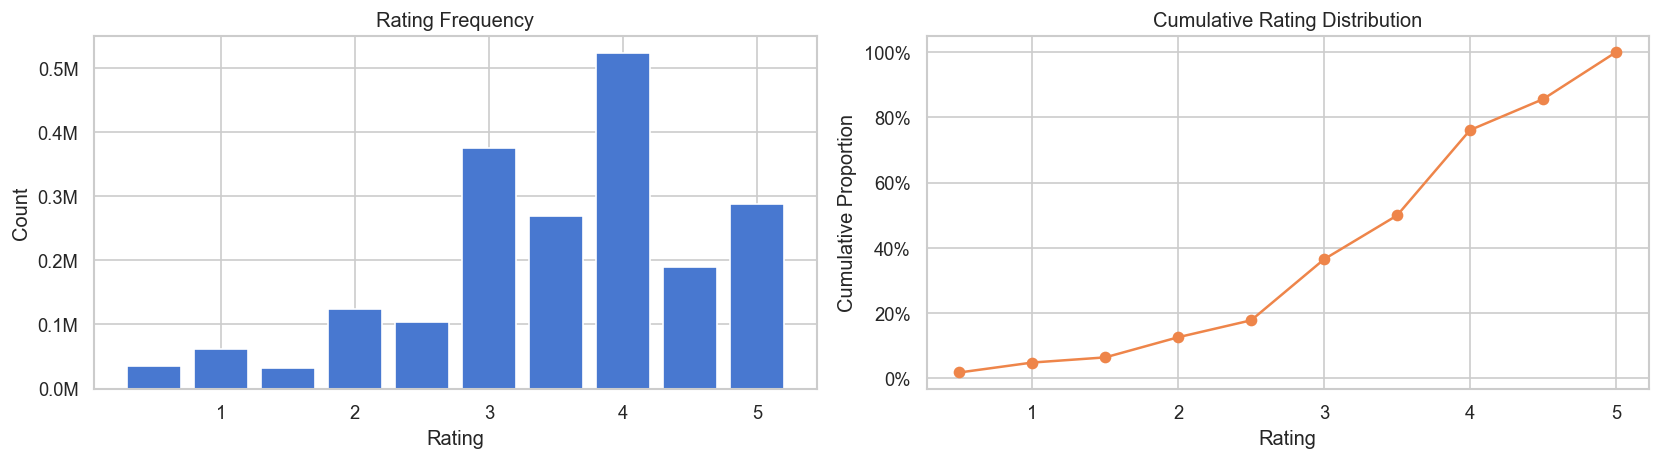

count    2.000000e+06
mean     3.542447e+00
std      1.064653e+00
min      5.000000e-01
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Count plot
rating_counts = ratings["rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, width=0.4, color=sns.color_palette("muted")[0])
axes[0].set_title("Rating Frequency")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Cumulative distribution
cumulative = rating_counts.cumsum() / rating_counts.sum()
axes[1].plot(cumulative.index, cumulative.values, marker="o", color=sns.color_palette("muted")[1])
axes[1].set_title("Cumulative Rating Distribution")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig(FIGS_DIR + "rating_distribution.png")
plt.show()

print(ratings["rating"].describe())


## 5. Ratings per User

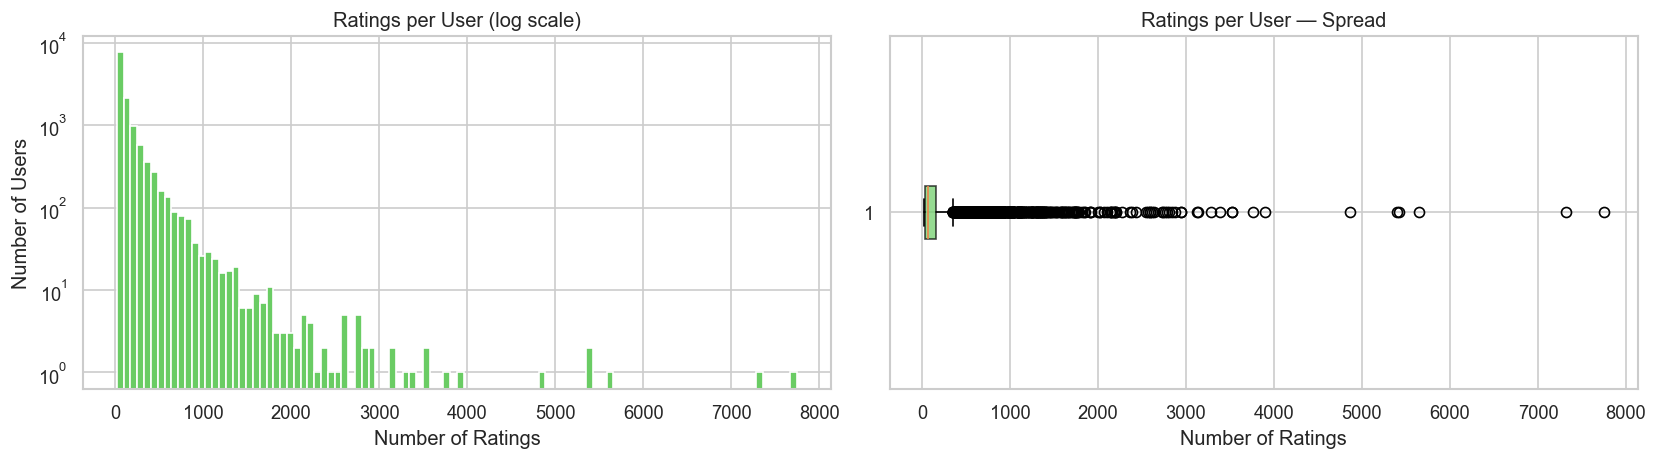

count    12773.000000
mean       156.580287
std        282.050769
min         20.000000
25%         36.000000
50%         71.000000
75%        163.000000
max       7748.000000
Name: rating, dtype: float64


In [13]:
ratings_per_user = ratings.groupby("userId")["rating"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram (log scale)
axes[0].hist(ratings_per_user, bins=100, color=sns.color_palette("muted")[2], edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Ratings per User (log scale)")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Users")

# Box plot
axes[1].boxplot(ratings_per_user, vert=False, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette("muted")[2], alpha=0.7))
axes[1].set_title("Ratings per User — Spread")
axes[1].set_xlabel("Number of Ratings")

plt.tight_layout()
plt.savefig(FIGS_DIR + "ratings_per_user.png")
plt.show()

print(ratings_per_user.describe())


## 6. Ratings per Movie

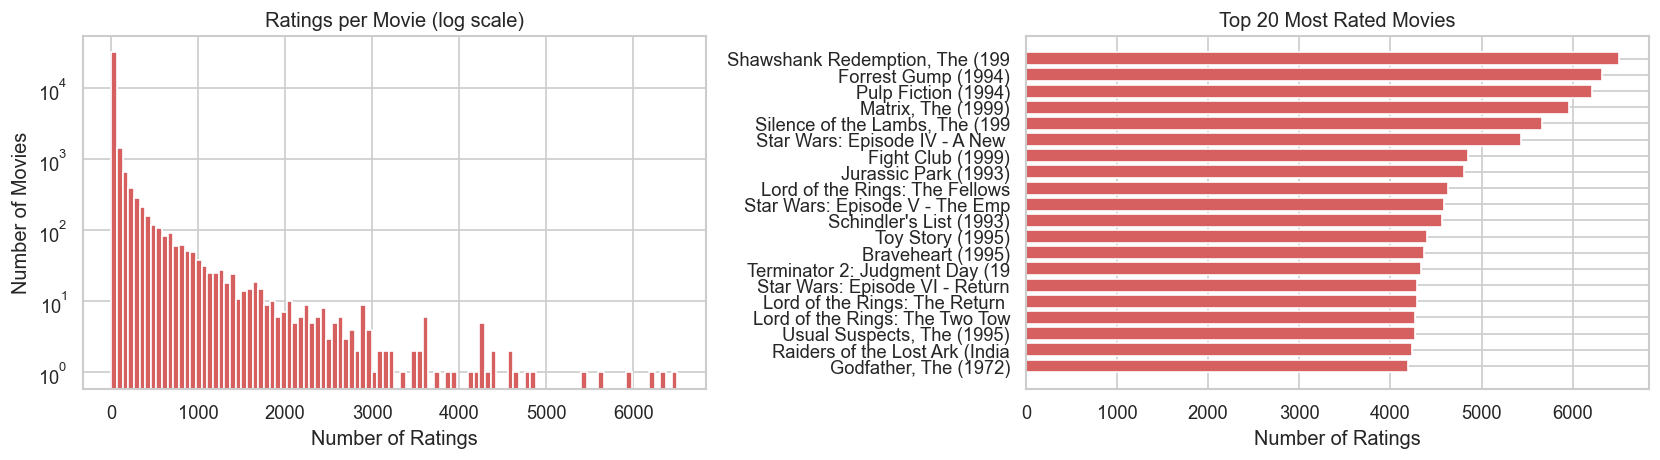

In [14]:
ratings_per_movie = ratings.groupby("movieId")["rating"].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ratings_per_movie, bins=100, color=sns.color_palette("muted")[3], edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Ratings per Movie (log scale)")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Movies")

# Top 20 most rated movies
top20_movies = ratings_per_movie.head(20).reset_index()
top20_movies = top20_movies.merge(movies[["movieId", "title"]], on="movieId")
top20_movies["short_title"] = top20_movies["title"].str[:30]

axes[1].barh(top20_movies["short_title"][::-1], top20_movies["rating"][::-1],
             color=sns.color_palette("muted")[3])
axes[1].set_title("Top 20 Most Rated Movies")
axes[1].set_xlabel("Number of Ratings")

plt.tight_layout()
plt.savefig(FIGS_DIR + "ratings_per_movie.png")
plt.show()


## 7. Top Movies by Average Rating

> We filter to movies with at least **100 ratings** to avoid small-sample bias.

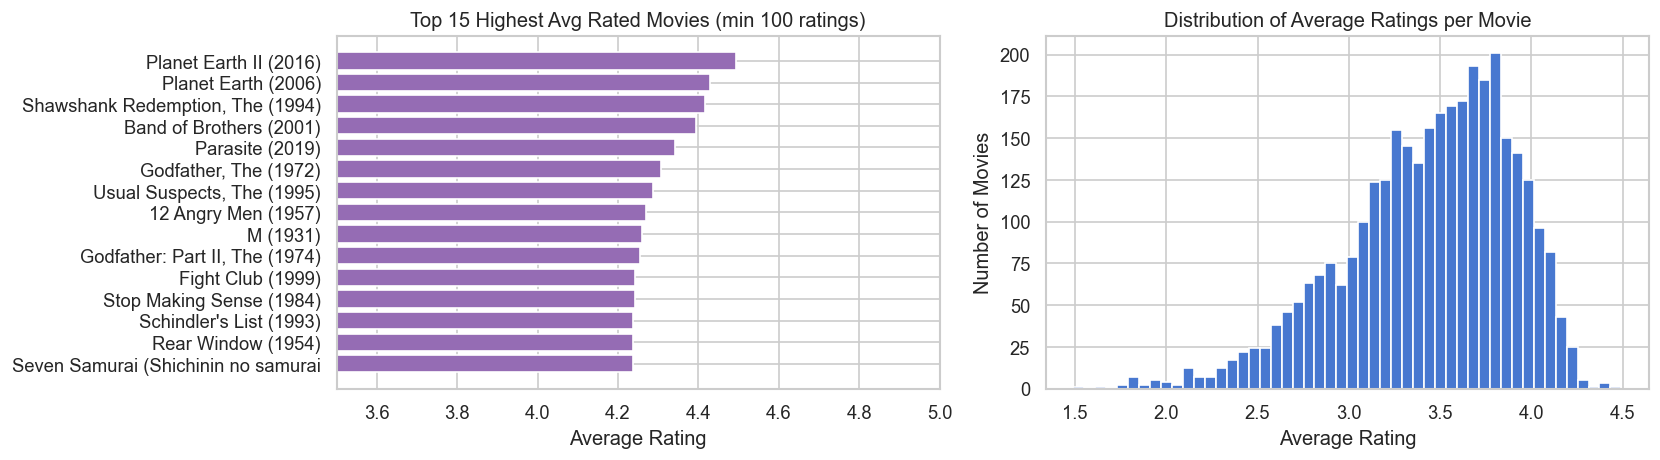

In [15]:
movie_stats = ratings.groupby("movieId")["rating"].agg(["mean", "count"]).reset_index()
movie_stats.columns = ["movieId", "avg_rating", "num_ratings"]
movie_stats = movie_stats.merge(movies[["movieId", "title"]], on="movieId")

# Filter: min 100 ratings
popular = movie_stats[movie_stats["num_ratings"] >= 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Top 15 highest rated
top15 = popular.nlargest(15, "avg_rating")
axes[0].barh(top15["title"].str[:35][::-1], top15["avg_rating"][::-1],
             color=sns.color_palette("muted")[4])
axes[0].set_xlim(3.5, 5.0)
axes[0].set_title("Top 15 Highest Avg Rated Movies (min 100 ratings)")
axes[0].set_xlabel("Average Rating")

# Distribution of average ratings
axes[1].hist(popular["avg_rating"], bins=50, color=sns.color_palette("muted")[0], edgecolor="white")
axes[1].set_title("Distribution of Average Ratings per Movie")
axes[1].set_xlabel("Average Rating")
axes[1].set_ylabel("Number of Movies")

plt.tight_layout()
plt.savefig(FIGS_DIR + "avg_rating_per_movie.png")
plt.show()


## 8. Genre Analysis

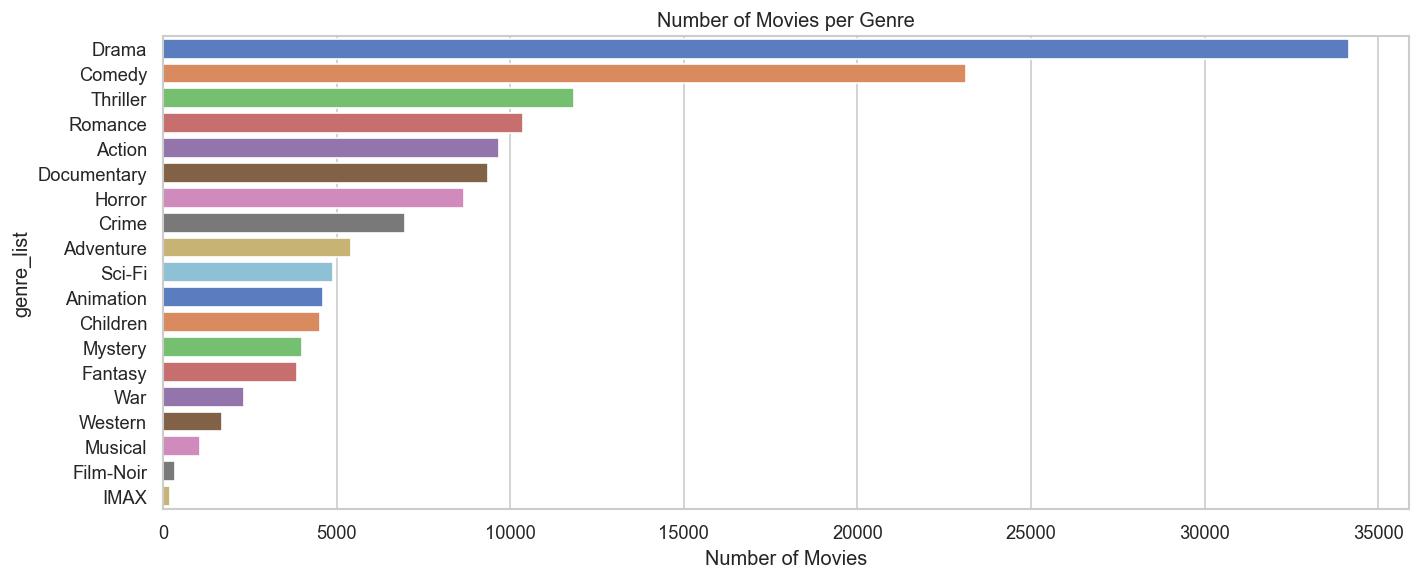

Total unique genres: 19
genre_list
Drama          34175
Comedy         23124
Thriller       11823
Romance        10369
Action          9668
Documentary     9363
Horror          8654
Crime           6976
Adventure       5402
Sci-Fi          4907
Animation       4617
Children        4520
Mystery         4013
Fantasy         3851
War             2325
Western         1696
Musical         1059
Film-Noir        353
IMAX             195
Name: count, dtype: int64


In [16]:
# Explode pipe-separated genres
movies["genre_list"] = movies["genres"].str.split("|")
all_genres = movies.explode("genre_list")
genre_counts = all_genres["genre_list"].value_counts()
genre_counts = genre_counts[genre_counts.index != "(no genres listed)"]

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="muted")
plt.title("Number of Movies per Genre")
plt.xlabel("Number of Movies")
plt.tight_layout()
plt.savefig(FIGS_DIR + "genre_distribution.png")
plt.show()

print(f"Total unique genres: {len(genre_counts)}")
print(genre_counts)


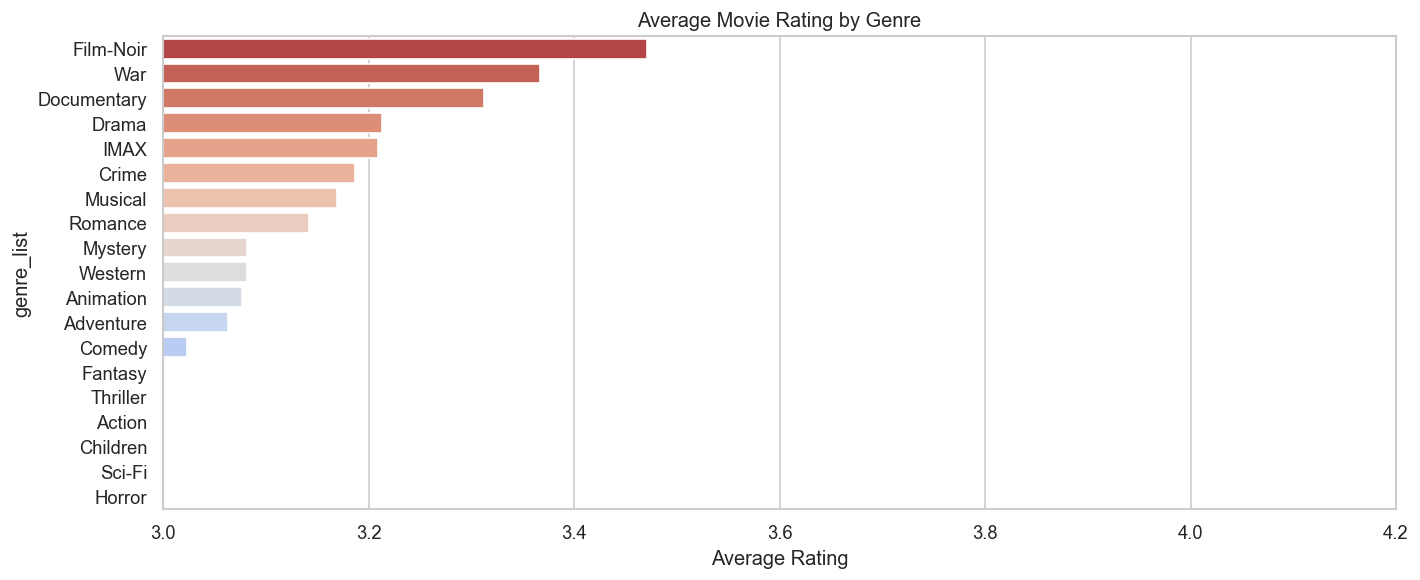

In [17]:
# Average rating per genre
genre_ratings = all_genres[["movieId", "genre_list"]].merge(
    movie_stats[["movieId", "avg_rating", "num_ratings"]], on="movieId"
)
genre_ratings = genre_ratings[genre_ratings["genre_list"] != "(no genres listed)"]
genre_avg = genre_ratings.groupby("genre_list")["avg_rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_avg.values, y=genre_avg.index, palette="coolwarm_r")
plt.title("Average Movie Rating by Genre")
plt.xlabel("Average Rating")
plt.xlim(3.0, 4.2)
plt.tight_layout()
plt.savefig(FIGS_DIR + "genre_avg_rating.png")
plt.show()


## 9. Rating Activity Over Time

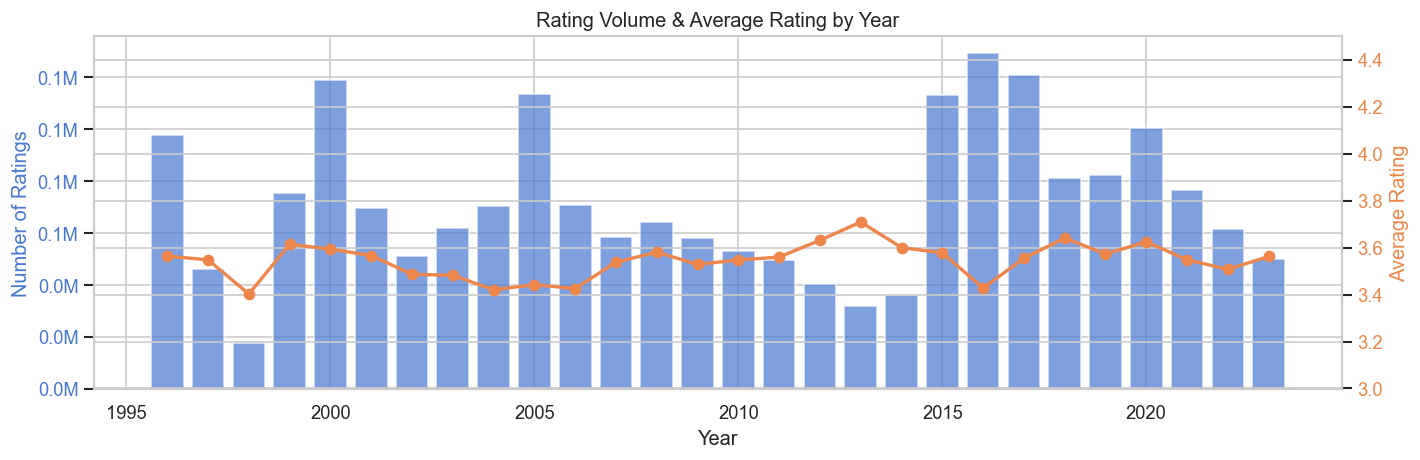

In [18]:
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings["year"] = ratings["datetime"].dt.year

yearly = ratings.groupby("year").agg(
    num_ratings=("rating", "count"),
    avg_rating=("rating", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 4))

color1 = sns.color_palette("muted")[0]
color2 = sns.color_palette("muted")[1]

ax1.bar(yearly["year"], yearly["num_ratings"], color=color1, alpha=0.7, label="# Ratings")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Ratings", color=color1)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(yearly["year"], yearly["avg_rating"], color=color2, marker="o", linewidth=2, label="Avg Rating")
ax2.set_ylabel("Average Rating", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(3.0, 4.5)

plt.title("Rating Volume & Average Rating by Year")
fig.tight_layout()
plt.savefig(FIGS_DIR + "ratings_over_time.png")
plt.show()


## 10. Tag Analysis

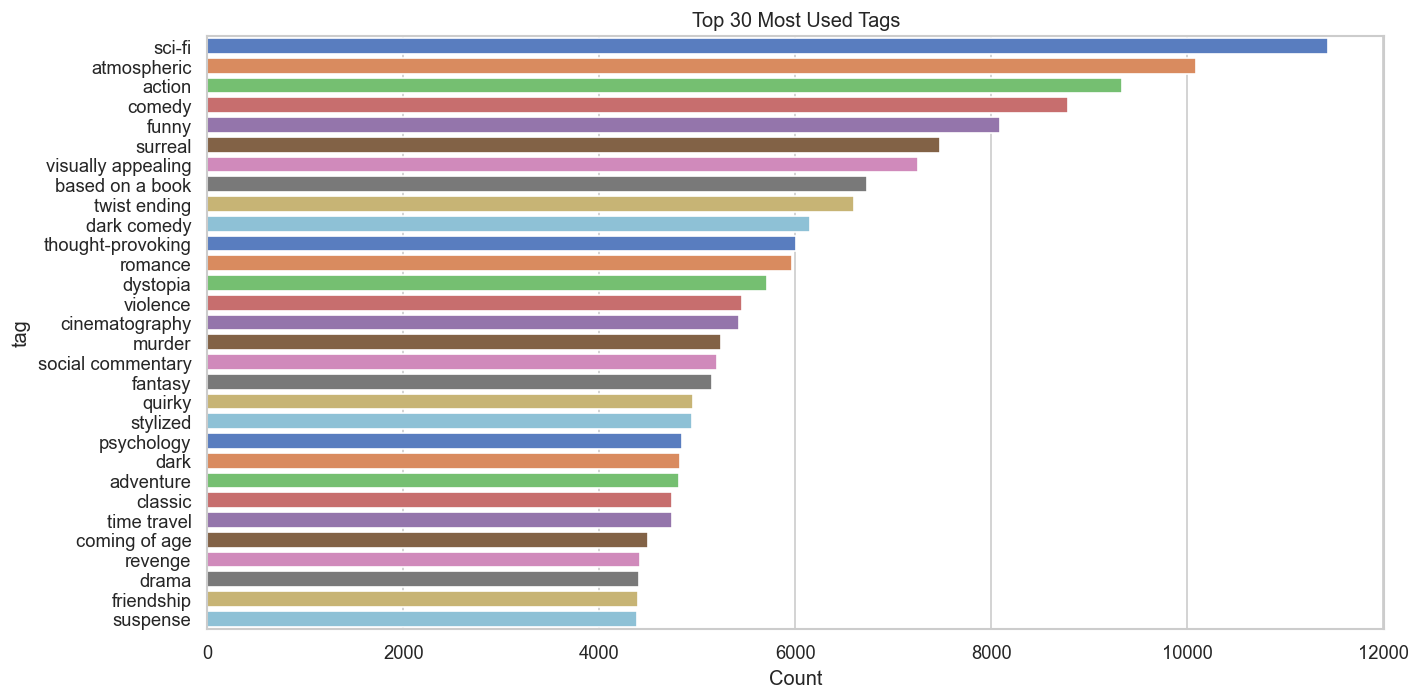

In [19]:
# Most common tags overall
top_tags = tags["tag"].str.lower().value_counts().head(30)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_tags.values, y=top_tags.index, palette="muted")
plt.title("Top 30 Most Used Tags")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(FIGS_DIR + "top_tags.png")
plt.show()

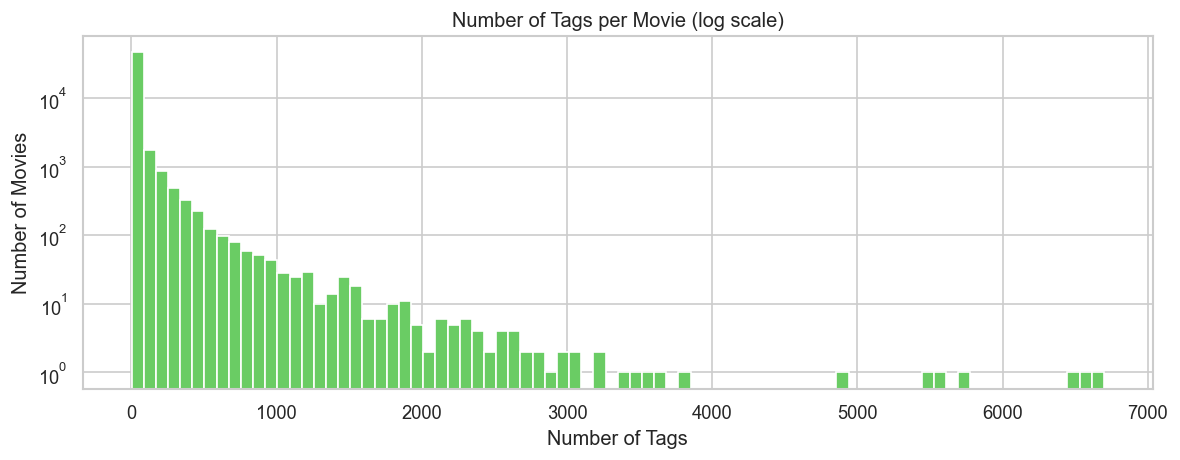

count    51323.000000
mean        38.969955
std        160.935295
min          1.000000
25%          2.000000
50%          5.000000
75%         16.000000
max       6697.000000
Name: tag, dtype: float64


In [20]:
# Tags per movie distribution
tags_per_movie = tags.groupby("movieId")["tag"].count().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.hist(tags_per_movie, bins=80, color=sns.color_palette("muted")[2], edgecolor="white")
plt.yscale("log")
plt.title("Number of Tags per Movie (log scale)")
plt.xlabel("Number of Tags")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig(FIGS_DIR + "tags_per_movie.png")
plt.show()

print(tags_per_movie.describe())


## 11. Movie Release Year Distribution

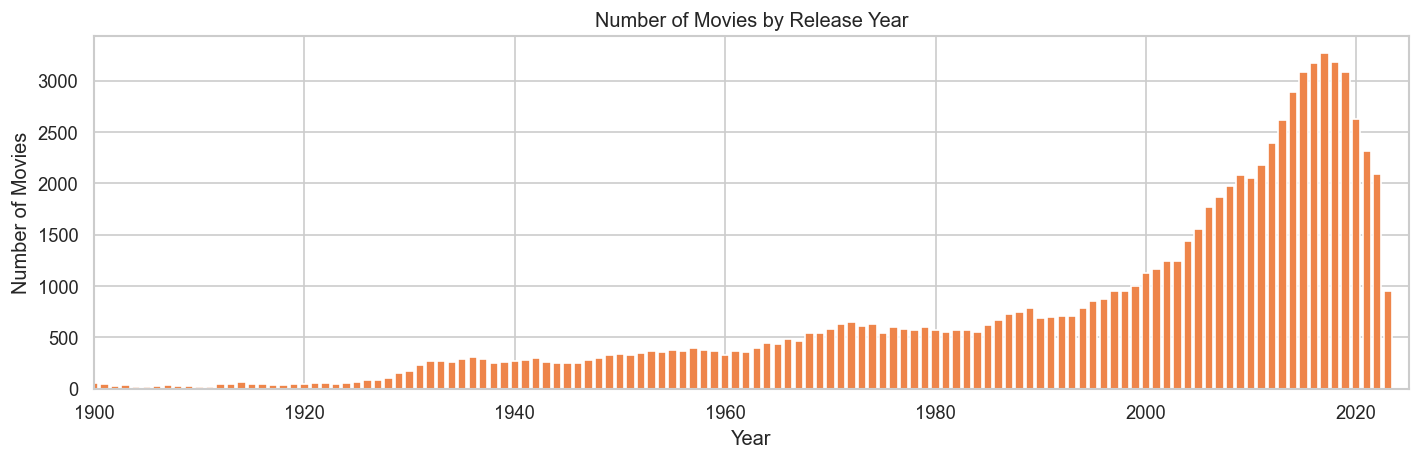

In [21]:
movies["release_year"] = movies["title"].str.extract(r"\((\d{4})\)$").astype(float)

plt.figure(figsize=(12, 4))
year_counts = movies["release_year"].dropna().value_counts().sort_index()
plt.bar(year_counts.index, year_counts.values, color=sns.color_palette("muted")[1], width=0.8)
plt.title("Number of Movies by Release Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.xlim(1900, 2025)
plt.tight_layout()
plt.savefig(FIGS_DIR + "release_year_distribution.png")
plt.show()

## 12. EDA Summary

| Finding | Detail |
|---|---|
| Dataset size | 32M ratings, 87.5K movies, 200K users |
| Matrix sparsity | ~99.8% sparse |
| Rating skew | Most ratings are 3.0–4.0 stars |
| User activity | Heavily right-skewed — few power users |
| Movie popularity | Few blockbusters dominate rating counts |
| Top genres | Drama, Comedy, Thriller most common |
| Highest rated genres | Film-Noir, War, Documentary |
| Rating trend | Volume peaks ~2015; avg rating stable ~3.5 |
| Tags | Short phrases; most movies have very few tags |

**Next step → `02_preprocessing.ipynb`**